<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    </a>
</p>

# Analyzing the Selected Socioeconomic Indicators in Chicago data-set with SQL and Python

## Objectives

*   Understand a dataset of selected socioeconomic indicators in Chicago
*   Store data in an SQLite database.
*   Explore the dataset with multiple variables and their correlation.


## Selected Socioeconomic Indicators in Chicago

The city of Chicago released a dataset of socioeconomic data to the Chicago City Portal.
This dataset contains a selection of six socioeconomic indicators of public health significance and a “hardship index,” for each Chicago community area, for the years 2008 – 2012.

Scores on the hardship index can range from 1 to 100, with a higher index number representing a greater level of hardship.

A detailed description of the dataset can be found on [the city of Chicago's website](https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01), but to summarize, the dataset has the following variables:

*   **Community Area Number** (`ca`): Used to uniquely identify each row of the dataset

*   **Community Area Name** (`community_area_name`): The name of the region in the city of Chicago

*   **Percent of Housing Crowded** (`percent_of_housing_crowded`): Percent of occupied housing units with more than one person per room

*   **Percent Households Below Poverty** (`percent_households_below_poverty`): Percent of households living below the federal poverty line

*   **Percent Aged 16+ Unemployed** (`percent_aged_16_unemployed`): Percent of persons over the age of 16 years that are unemployed

*   **Percent Aged 25+ without High School Diploma** (`percent_aged_25_without_high_school_diploma`): Percent of persons over the age of 25 years without a high school education

*   **Percent Aged Under** 18 or Over 64:Percent of population under 18 or over 64 years of age (`percent_aged_under_18_or_over_64`): (ie. dependents)

*   **Per Capita Income** (`per_capita_income_`): Community Area per capita income is estimated as the sum of tract-level aggragate incomes divided by the total population

*   **Hardship Index** (`hardship_index`): Score that incorporates each of the six selected socioeconomic indicators

In this project, we'll take a look at the variables in the socioeconomic indicators dataset and do some basic analysis with Python.


### Connect to the database

Let us first load the SQL extension and establish a connection with the database

##### The syntax for connecting to magic sql using sqllite is

  **%sql sqlite://DatabaseName**   
  
where DatabaseName will be your **.db** file 


In [1]:
!pip install ipython-sql
!pip install seaborn
import seaborn as sns
%load_ext sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 168.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 166.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 155.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 151.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 144.4 MB/s eta 0:00:00


In [2]:
import csv, sqlite3

con = sqlite3.connect("socioeconomic.db")
cur = con.cursor()
!pip install pandas 

In [3]:
%sql sqlite:///socioeconomic.db

### Store the dataset in a Table

##### In many cases the dataset to be analyzed is available as a .CSV (comma separated values) file, perhaps on the internet. To analyze the data using SQL, it first needs to be stored in the database.

##### We will first read the csv files  from the given url  into pandas dataframes

##### Next we will be using the  df.to_sql() function to convert each csv file  to a table in sqlite  with the csv data loaded in it.



In [4]:
import pandas
df = pandas.read_csv('https://data.cityofchicago.org/resource/jcxq-k9xf.csv')
df.to_sql("chicago_socioeconomic_data", con, if_exists='replace', index=False,method="multi")


78

In [5]:
# Install the 'ipython-sql' and 'prettytable' libraries using pip
!pip install ipython-sql prettytable

# Import the 'prettytable' library, which is used to display data in a formatted table
import prettytable

# Set the default display format for prettytable to 'DEFAULT' (i.e., a simple table format)
prettytable.DEFAULT = 'DEFAULT'

##### We can verify that the table creation was successful by making a basic query like:


In [6]:
%sql SELECT * FROM chicago_socioeconomic_data limit 5;

 * sqlite:///socioeconomic.db
Done.


ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0


## Exploratory Analysis

### Exploratory Analysis 1

##### How many rows are in the dataset?


In [10]:
%%sql 
SELECT COUNT(*) 
FROM chicago_socioeconomic_data;

 * sqlite:///socioeconomic.db
Done.


COUNT(*)
78


In [11]:
## 78 rows are in the dataset

### Exploratory Analysis 2

##### How many community areas in Chicago have a hardship index greater than 50.0?


In [13]:
%%sql 
SELECT COUNT(*) 
FROM chicago_socioeconomic_data
WHERE hardship_index > 50.0;

 * sqlite:///socioeconomic.db
Done.


COUNT(*)
38


In [14]:
# 38 community areas in Chicago have a hardship index greater than 50.0.

### Exploratory Analysis 3

##### What is the maximum value of hardship index in this dataset?


In [16]:
%%sql
SELECT MAX(hardship_index)
FROM chicago_socioeconomic_data;


 * sqlite:///socioeconomic.db
Done.


MAX(hardship_index)
98.0


In [17]:
# The maximum value of hardship index in this dataset is 98.

### Exploratory Analysis 4

##### Which community area which has the highest hardship index?


In [19]:
#We can use the result of the last query to as an input to this query:
%sql SELECT community_area_name FROM chicago_socioeconomic_data where hardship_index=98.0;

#or another option:
%sql SELECT community_area_name FROM chicago_socioeconomic_data ORDER BY hardship_index DESC LIMIT 1;

#or we can use a sub-query to determine the max hardship index:
%sql select community_area_name from chicago_socioeconomic_data where hardship_index = ( select max(hardship_index) from chicago_socioeconomic_data );



 * sqlite:///socioeconomic.db
Done.


ca,community_area_name
54.0,Riverdale


In [22]:
# Riverdale has the highest hardship index.

### Exploratory Analysis 5

##### Which Chicago community areas have per-capita incomes greater than $60,000?


In [24]:
%%sql
SELECT ca,community_area_name
FROM chicago_socioeconomic_data
WHERE per_capita_income_ > 60000;

 * sqlite:///socioeconomic.db
Done.


ca,community_area_name
6.0,Lake View
7.0,Lincoln Park
8.0,Near North Side
32.0,Loop


In [27]:
# Lake View, Lincoln Park, Near North Side, Loop have per-capita incomes greater than $60,000.

### Exploratory Analysis 6

##### Create a scatter plot using the variables `per_capita_income_` and `hardship_index`. Explore the correlation between the two variables.


In [31]:
chicago_data = %sql SELECT * FROM chicago_socioeconomic_data;
df = chicago_data.DataFrame()

 * sqlite:///socioeconomic.db
Done.


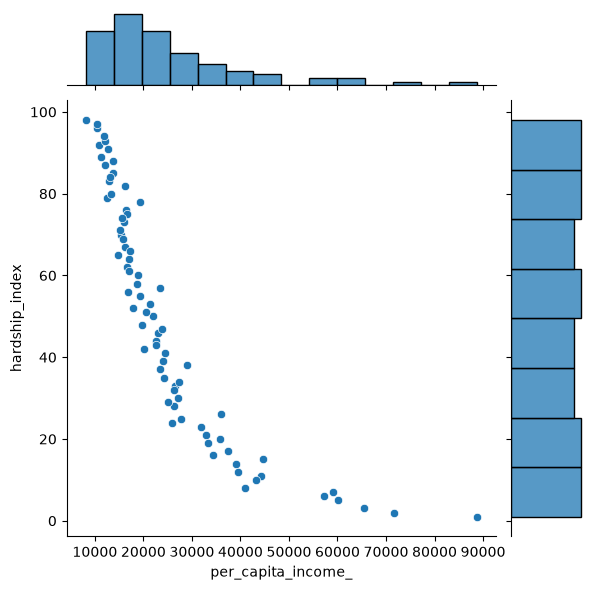

In [34]:
!pip install matplotlib
%matplotlib inline
#plot = sns.scatterplot(x="per_capita_income_",y="hardship_index",data=df)
plot2 = sns.jointplot(x="per_capita_income_",y="hardship_index",data=df)
# The per_capita_income_ and hardship_index has negative correlation, the higher the per_capita_income_, the lower the hardship_index.

### Exploratory Analysis 7

##### How the variable per_capita_income_ is related to percent_households_below_poverty:

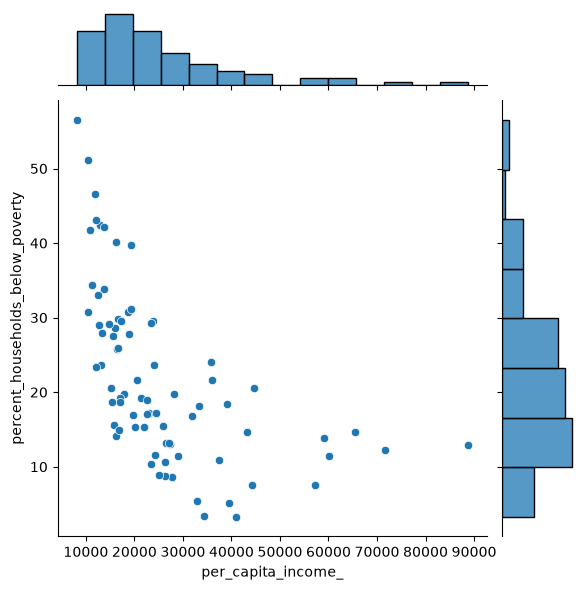

In [36]:
plot3 = sns.jointplot(x="per_capita_income_",y="percent_households_below_poverty",data=df)
# negative correlation

### Exploratory Analysis 8

##### How the variable per_capita_income_ is related to percent_aged_16_unemployed:

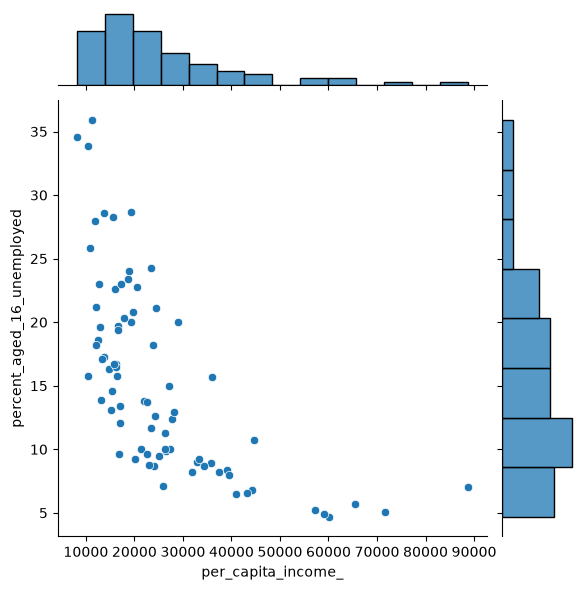

In [38]:
plot4 = sns.jointplot(x="per_capita_income_",y="percent_aged_16_unemployed",data=df) 
# negative correlation